In [1]:
%config Completer.use_jedi = False

In [2]:
# load module
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorboard as tb 
import pytorch_lightning as pl

from pathlib import Path
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters


import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

from my_funs import data_processing , get_training , countious_prediction

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [3]:
# 앞에서 결정된 ewma에 대해서만 학습 진행
ewma_list2 = ['alpha1/03.csv' , 'com1/1.csv' , 'com1/2.csv', 'span1/3.csv' , 'span1/5.csv', 'halflife1/1.csv', 'halflife1/3.csv']
lr_list = [1e-0,1e-1,1e-2, 1e-3, 1e-4, 1e-5 ]

# 1 ~ 1e-5 

In [4]:
for lr in lr_list:
    print(lr)

1.0
0.1
0.01
0.001
0.0001
1e-05


In [5]:
result_list = [] 
for lr in lr_list:
    print(lr , 'alpha1/03.csv')
    data = data_processing('alpha1/03.csv')
    #test_data = data.copy(deep=True)
    train_data = data[data['time_idx']  < 8760]
    training = get_training(train_data,24, 24*7)

    batch_size= 32
    dataloader = training.to_dataloader(batch_size)
    validation = TimeSeriesDataSet.from_dataset(training, train_data, predict=True, stop_randomization=True)
    train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size*100, num_workers=0)
    
    epoch = 200
    hidden_size = 32
    atten_head = 4

    pl.seed_everything(42)

    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
    lr_logger = LearningRateMonitor()  
    logger = TensorBoardLogger('lr_test_ewma1')
    trainer = pl.Trainer(
        max_epochs=epoch,
        gpus=0,
        gradient_clip_val=0.1,
        limit_train_batches=5,  
        callbacks=[lr_logger],
        logger=logger,
    )


    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=lr,
        hidden_size=hidden_size,  # most important hyperparameter apart from learning rate
        # number of attention heads. Set to up to 4 for large datasets
        attention_head_size=atten_head,
        dropout=0.1,  # between 0.1 and 0.3 are good values
        hidden_continuous_size=hidden_size,  # set to <= hidden_size
        output_size=7,  # 7 quantiles by default
        loss=QuantileLoss(),
        # reduce learning rate if no improvement in validation loss after x epochs
        reduce_on_plateau_patience=4,
    )
        
    tft.hparams['optimizer'] = 'RAdam'
    
    trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
    )

    print(trainer.checkpoint_callback.best_model_path)
    result_list.append(trainer.checkpoint_callback.best_model_path)


1.0 alpha1/03.csv


Global seed set to 42
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params
----------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0     
1  | logging_metrics                    | ModuleList                      | 0     
2  | input_embeddings                   | MultiEmbedding                  | 189   
3  | prescalers                         | ModuleDict                      | 192   
4  | static_variable_selection          | VariableSelectionNetwork        | 4.6 K 
5  | encoder_variable_selection         | VariableSelectionNetwork        | 8.9 K 
6  | decoder_variable_selection         | VariableSelectionNetwork        | 4.4 K 
7  | static_context_variable_selection  | GatedResidualNetwork         

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


lr_test_ewma1/lightning_logs/version_14/checkpoints/epoch=199-step=1000.ckpt


In [6]:
result_list

['lr_test_ewma1/lightning_logs/version_9/checkpoints/epoch=199-step=1000.ckpt',
 'lr_test_ewma1/lightning_logs/version_10/checkpoints/epoch=199-step=1000.ckpt',
 'lr_test_ewma1/lightning_logs/version_11/checkpoints/epoch=199-step=1000.ckpt',
 'lr_test_ewma1/lightning_logs/version_12/checkpoints/epoch=199-step=1000.ckpt',
 'lr_test_ewma1/lightning_logs/version_13/checkpoints/epoch=199-step=1000.ckpt',
 'lr_test_ewma1/lightning_logs/version_14/checkpoints/epoch=199-step=1000.ckpt']

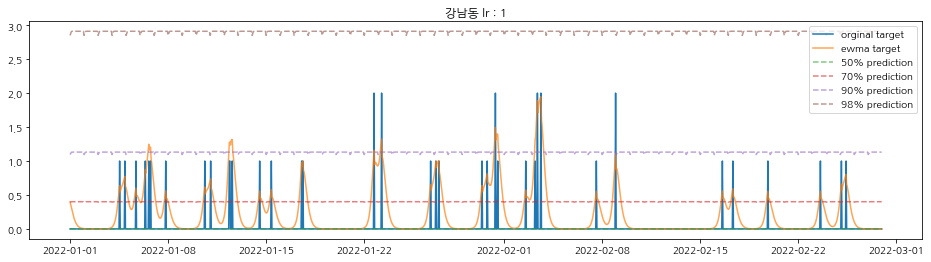

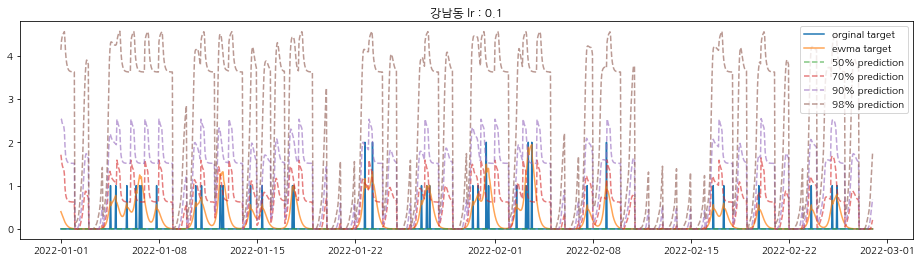

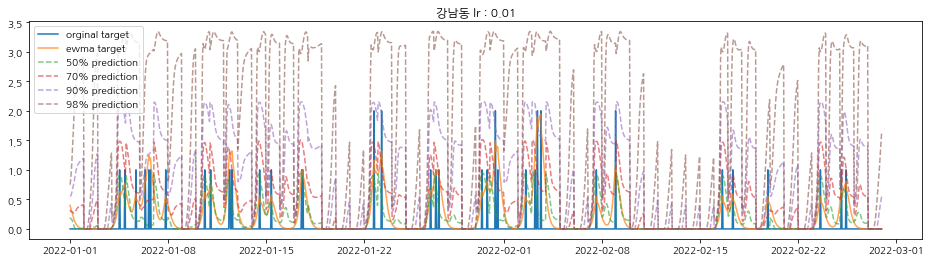

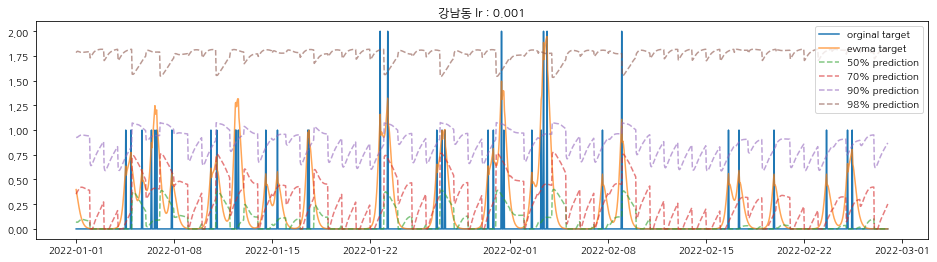

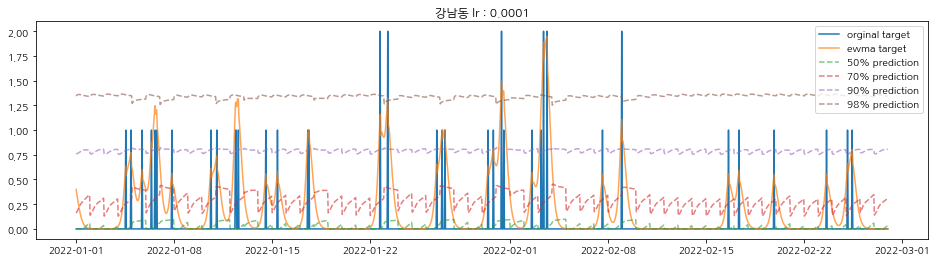

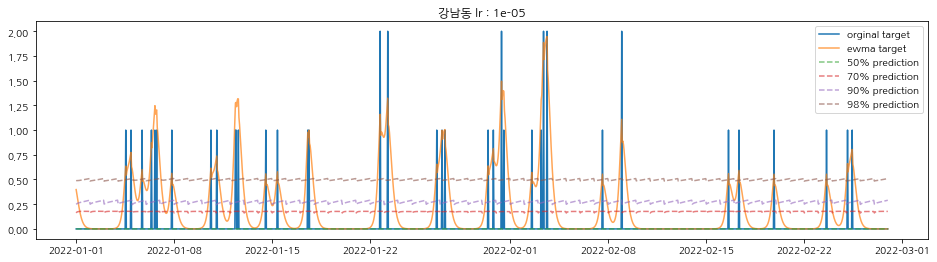

In [7]:
for i,ckpt in enumerate(result_list):
    data = data_processing('alpha2/03.csv')
    train_data = data[data['time_idx']  < 8760]
    training = get_training(train_data,24, 24*7)
    tft = TemporalFusionTransformer.load_from_checkpoint(ckpt)
    countious_prediction(training, tft, data, '강남동' , f'lr : {10**(-i)}')